# create split_dict

In [ ]:
import numpy as np
import pickle

# Create reduced training sets (50% and 25%)
def create_reduced_split(original_split_dict, train_fraction=0.5, seed=42):
    """
    Create a new split_dict with reduced training set.
    Keeps val and test unchanged. Ensures 'ctrl' is always in train.
    
    Args:
        original_split_dict: dict with 'train', 'val', 'test' keys
        train_fraction: fraction of original training perturbations to keep (relative to 75%)
        seed: random seed for reproducibility
    """
    np.random.seed(seed)
    
    # Copy val and test (unchanged)
    new_split = {
        'val': original_split_dict['val'].copy(),
        'test': original_split_dict['test'].copy()
    }
    
    # Get training perturbations
    train_perts = original_split_dict['train'].copy()
    
    # Separate 'ctrl' from other perturbations
    if 'ctrl' in train_perts:
        train_perts_no_ctrl = [p for p in train_perts if p != 'ctrl']
        has_ctrl = True
    else:
        train_perts_no_ctrl = train_perts
        has_ctrl = False
    
    # Calculate how many perturbations to keep
    # train_fraction is relative to the original total conditions
    n_total = len(original_split_dict['train']) + len(original_split_dict['val']) + len(original_split_dict['test'])
    n_keep = int(n_total * train_fraction)
    
    # Randomly sample perturbations
    selected_perts = np.random.choice(train_perts_no_ctrl, size=n_keep, replace=False).tolist()
    
    # Always include 'ctrl' in training
    if has_ctrl:
        selected_perts = ['ctrl'] + selected_perts
    
    new_split['train'] = selected_perts
    
    return new_split

def create_and_save_reduced_splits(ds_name, split, train_fractions=[0.5, 0.25], seed=42):
    """
    Create and save reduced splits for given dataset and split.
    
    Args:
        ds_name: dataset name
        split: split identifier
        train_fractions: list of fractions for training set reduction
        seed: random seed for reproducibility
    """
    # Load original split_dict
    original_split_dict = pickle.load(open(f"./data/gears/{ds_name}/splits/{ds_name}_single_{split}_0.75.pkl", "rb"))
    n_total = len(original_split_dict['train']) + len(original_split_dict['val']) + len(original_split_dict['test'])

    print("Original split (75%):")
    print(f"  Train: {len(original_split_dict['train'])} perturbations")
    print(f"  Val: {len(original_split_dict['val'])} perturbations")
    print(f"  Test: {len(original_split_dict['test'])} perturbations")
    print(f"  'ctrl' in train: {'ctrl' in original_split_dict['train']}")
    
    for frac in train_fractions:
        new_split_dict = create_reduced_split(original_split_dict, train_fraction=frac, seed=seed)

        print(f"\n{int(frac*100)}% training split:")
        print(f"  Train: {len(new_split_dict['train'])} ({len(new_split_dict['train'])/n_total:.1%}) perturbations")
        print(f"  Val: {len(new_split_dict['val'])} ({len(new_split_dict['val'])/n_total:.1%}) perturbations")
        print(f"  Test: {len(new_split_dict['test'])} ({len(new_split_dict['test'])/n_total:.1%}) perturbations")
        print(f"  'ctrl' in train: {'ctrl' in new_split_dict['train']}")
        
        # Save new split_dict
        output_path = f"./data/sample_size_test/splits/{ds_name}_single_{split}_{frac}.pkl"
        with open(output_path, "wb") as f:
            pickle.dump(new_split_dict, f)
        print(f"Saved reduced split with {frac*100}% training perturbations to {output_path}")

In [ ]:
for ds_name in ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']:
    for split in ['1', '2', '3']:
        print(f"Processing Dataset: {ds_name}, Split: {split}")
        # Use different seed for each split to get different random samples
        create_and_save_reduced_splits(ds_name, split, train_fractions=[0.5, 0.25, 0.1, 0.05, 0.025], seed=42)

# Training

## GFM

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)
# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="${adata_paths[$i]}"
    
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            split_path="../data/sample_size_test/splits/${dataset}_single_${split}_${fraction}.pkl"
            working_dir="../data/sample_size_test/gfm/${dataset}/split_${split}_frac_${fraction}"
            
            python ../scripts/gfm_run_all.py \
                --adata-path ${adata_path} \
                --split-dict-path ${split_path} \
                --output_dir ${working_dir} \
                --model-name "gfm_go+gwps+ppi_gat.pt" \
                --graph-type "go+pert+ppi" \
                --graph-dir "../data/"        
        done
    done
done


## GEARS

use gears env

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="${adata_paths[$i]}"
    
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            seed="${split}_${fraction}"
            split_path="../data/sample_size_test/splits/${dataset}_single_${seed}.pkl"
            pert_data_dir="../data/gears/${dataset}"
            save_dir="../data/sample_size_test/gears/${dataset}/split_${split}_frac_${fraction}"
            
            python ../scripts/gears_train.py ${pert_data_dir} ${seed} ${split_path} ${save_dir}
        done
    done
done

## CellFlow

use cellflow env

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)


# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="${adata_paths[$i]}"
    
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            split_path="../data/sample_size_test/splits/${dataset}_single_${split}_${fraction}.pkl"
            working_dir="../data/sample_size_test/cellflow/${dataset}/split_${split}_frac_${fraction}"
            
            python ../scripts/cellflow_train.py ${adata_path} ${split_path} ${split} ${working_dir}
        done
    done
done


## scGPT
use scgpt env

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')

# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            split_path="../data/sample_size_test/splits/${dataset}_single_${split}_${fraction}.pkl"
            pert_data_dir="../data/gears/${dataset}"
            save_dir="../data/sample_size_test/scgpt/${dataset}/split_${split}_frac_${fraction}"
            load_model="../data/scgpt/pretrained_model_whole-human"

            python ../scripts/scgpt_train.py ${pert_data_dir} ${split_path} ${split} ${save_dir} ${load_model}
        done
    done
done

## Linear

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="${adata_paths[$i]}"
    
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            split_path="../data/sample_size_test/splits/${dataset}_single_${split}_${fraction}.pkl"
            working_dir="../data/sample_size_test/linear_model/${dataset}/split_${split}_frac_${fraction}"

            python ../scripts/linear_model_train.py ${adata_path} ${split_path} ${working_dir} ${split}
            
        done
    done
done

# compute all metrics

## GFM

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="${adata_paths[$i]}"
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            split_path="../data/sample_size_test/splits/${dataset}_single_${split}_${fraction}.pkl"
            adata_pred_path="../data/sample_size_test/gfm/${dataset}/split_${split}_frac_${fraction}/adata_pred_gfm_go+gwps+ppi_gat.h5ad"
            results_path="../data/sample_size_test/gfm/${dataset}/split_${split}_frac_${fraction}/results_test_gfm_go+gwps+ppi_gat.csv"
            
            python ../scripts/evaluate_pred.py ${adata_path} ${adata_pred_path} ${split_path} ${results_path}
        done
    done
done

## CellFlow

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="${adata_paths[$i]}"
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            split_path="../data/sample_size_test/splits/${dataset}_single_${split}_${fraction}.pkl"
            adata_pred_path="../data/sample_size_test/cellflow/${dataset}/split_${split}_frac_${fraction}/adata_pred_${split}.h5ad"
            results_path="../data/sample_size_test/cellflow/${dataset}/split_${split}_frac_${fraction}/results_test.csv"

            python ../scripts/evaluate_pred.py ${adata_path} ${adata_pred_path} ${split_path} ${results_path}
        done
    done
done

## GEARS

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="${adata_paths[$i]}"
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            split_path="../data/sample_size_test/splits/${dataset}_single_${split}_${fraction}.pkl"
            adata_pred_path="../data/sample_size_test/gears/${dataset}/split_${split}_frac_${fraction}/adata_pred_${split}_${fraction}.h5ad"
            results_path="../data/sample_size_test/gears/${dataset}/split_${split}_frac_${fraction}/results_test.csv"

            python ../scripts/evaluate_pred.py ${adata_path} ${adata_pred_path} ${split_path} ${results_path}
        done
    done
done

## scGPT

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="${adata_paths[$i]}"
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            split_path="../data/sample_size_test/splits/${dataset}_single_${split}_${fraction}.pkl"
            adata_pred_path="../data/sample_size_test/scgpt/${dataset}/split_${split}_frac_${fraction}/adata_pred_${split}.h5ad"
            results_path="../data/sample_size_test/scgpt/${dataset}/split_${split}_frac_${fraction}/results_test.csv"
        
            python ../scripts/evaluate_pred.py ${adata_path} ${adata_pred_path} ${split_path} ${results_path}
        done
    done
done

## Pert train

In [ ]:
%%bash

# Define datasets to iterate over
datasets=('replogle_k562' 'replogle_rpe1' 'nadig_hepg2' 'nadig_jurkat')
adata_paths=(
    "../data/preprocessed_replogle_k562.h5ad"
    "../data/preprocessed_replogle_rpe1.h5ad"
    "../data/preprocessed_nadig_hepg2.h5ad"
    "../data/preprocessed_nadig_jurkat.h5ad"
)

# Define splits and fractions to iterate over
splits=(1 2 3)
fractions=(0.5 0.25 0.1 0.05 0.025)

# Iterate over all combinations
for i in "${!datasets[@]}"; do
    dataset="${datasets[$i]}"
    adata_path="${adata_paths[$i]}"
    for split in "${splits[@]}"; do
        for fraction in "${fractions[@]}"; do
            split_path="../data/sample_size_test/splits/${dataset}_single_${split}_${fraction}.pkl"
            results_path="../data/sample_size_test/pert_train/${dataset}/split_${split}_frac_${fraction}/results_test.csv"

            python ../scripts/compute_baseline_metrics.py ${adata_path} ${split_path} ${results_path}
        done
    done
done

# Evaluation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

import json
model_color_dict = json.load(open("../data/model_color_dict.json", "r"))
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 8

In [5]:
%load_ext autoreload
%autoreload 2

from gfm.helpers import calculate_delta_result

In [ ]:
working_dir = "../data/sample_size_test/"
model_names = ["gfm", "gears", "cellflow", "scgpt", "linear_model"]
ds_list = ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']
split_list = ['1', '2', '3']
fraction_list = ['0.5', '0.25', '0.1', '0.05', '0.025']

In [ ]:
# read 0.75 first
## GFM
results = []
for ds in ds_list:
    for split in split_list:
        result_dict = {
            'GFM': f"../data/gfm/{ds}/split_{split}/results_test_gfm_go+gwps+ppi_gat.csv",
            'Perturb train': f"../data/pert_train/{ds}/results_test_{split}.csv"
        }
        result_df = pd.read_csv(result_dict['GFM'])
        result_no_change = pd.read_csv(result_dict['Perturb train'])
        result_combined = calculate_delta_result(result_df, result_no_change, normalize=False)
        result_combined['model'] = 'gfm'
        result_combined['fraction'] = '0.75'
        result_combined['dataset'] = ds
        result_combined['split'] = split
        results.append(result_combined)

## GEARS, cellflow, scgpt
models = ['gears', 'cellflow', 'scgpt', 'linear_model']
for model in models:
    for ds in ds_list:
        for split in split_list:
            result_dict = {
                'Model': f"../data/{model}/{ds}/results_test_{split}.csv",
                'Perturb train': f"../data/pert_train/{ds}/results_test_{split}.csv"
            }
            result_df = pd.read_csv(result_dict['Model'])
            result_no_change = pd.read_csv(result_dict['Perturb train'])
            result_combined = calculate_delta_result(result_df, result_no_change, normalize=False)
            result_combined['model'] = model
            result_combined['fraction'] = '0.75'
            result_combined['dataset'] = ds
            result_combined['split'] = split
            results.append(result_combined)

In [9]:
# read 0.5 and 0.25
for model_name in model_names:
    for ds in ds_list:
        for split in split_list:
            for frac in fraction_list:
                if model_name == "gfm":
                    result_file = f"{working_dir}/{model_name}/{ds}/split_{split}_frac_{frac}/results_test_gfm_go+gwps+ppi_gat.csv"
                elif model_name == "linear_model":
                    result_file = f"{working_dir}/{model_name}/{ds}/split_{split}_frac_{frac}/results_test_{split}.csv"
                else:                    
                    result_file = f"{working_dir}/{model_name}/{ds}/split_{split}_frac_{frac}/results_test.csv"
                result_dict = {
                    'Model': result_file,
                    'Perturb train': f"{working_dir}/pert_train/{ds}/split_{split}_frac_{frac}/results_test.csv"
                }
                result_df = pd.read_csv(result_dict['Model'])
                result_no_change = pd.read_csv(result_dict['Perturb train'])
                result_combined = calculate_delta_result(result_df, result_no_change, normalize=False)
                result_combined['model'] = model_name
                result_combined['fraction'] = frac
                result_combined['dataset'] = ds
                result_combined['split'] = split
                results.append(result_combined)

In [10]:
df_all = pd.concat(results, ignore_index=True)

In [ ]:
df_all.head()

,mse,pearson,spearman,mmd,pearson_delta,w2d,e_distance,condition,model,fraction,dataset,split
0,0.003571,-0.000793,-0.001504,0.115758,0.148872,-0.340576,0.385371,DDB1+ctrl,otcfm,0.75,replogle_k562,1
1,-0.006456,0.002063,0.003008,0.137180,0.412137,-0.409971,0.352421,NBAS+ctrl,otcfm,0.75,replogle_k562,1
2,-0.024105,0.004408,0.009023,0.158980,0.685720,-0.427338,0.241801,PDRG1+ctrl,otcfm,0.75,replogle_k562,1
3,0.103224,-0.002690,0.001504,0.232570,0.009137,0.143781,1.300222,RUVBL1+ctrl,otcfm,0.75,replogle_k562,1
4,-0.064218,0.012379,0.025564,0.205007,0.726342,-0.552230,0.433972,TNPO3+ctrl,otcfm,0.75,replogle_k562,1


In [ ]:
def plot_metrics_grid(df, datasets, metrics, figsize=None, model_color_dict=None, save_path=None):
    """
    Create a grid of subplots with different metrics (rows) and datasets (columns).
    
    Args:
        df: DataFrame containing the results
        datasets: List of dataset names to plot
        metrics: List of metric column names to plot
        figsize: Optional tuple for figure size (default: auto-calculated)
        model_color_dict: Optional dict mapping model names to colors
        save_path: Optional path to save the figure
    """
    import seaborn as sns
    
    # Map model names to color dict keys
    model_name_map = {'otcfm': 'GFM', 'gears': 'GEARS', 'cellflow': 'CellFlow', 'scgpt': 'scGPT', 'linear_model': 'Linear'}
    df = df.copy()
    df['model_display'] = df['model'].map(model_name_map).fillna(df['model'])

    metric_labels = {
        'mse': 'Δ MSE',
        'pearson': 'Δ Pearson r',
        'spearman': 'Δ Spearman r',
        'mmd': 'Δ MMD',
        'pearson_delta': 'Pearson Delta',
        'w2d': 'Δ 2-WD',
        'e_distance': 'Δ E-Distance'
    }

    
    # Create color palette from model_color_dict
    palette = {k: v for k, v in model_color_dict.items()} if model_color_dict else None
    
    n_metrics = len(metrics)
    n_datasets = len(datasets)
    
    if figsize is None:
        figsize = (7, 8)
    
    if metric_labels is None:
        metric_labels = {m: m.capitalize() for m in metrics}
    
    fig, axes = plt.subplots(n_metrics, n_datasets, figsize=figsize, squeeze=False)
    legend_handles = None
    legend_labels = None
    
    for i, metric in enumerate(metrics):
        for j, dataset in enumerate(datasets):
            ax = axes[i, j]
            to_plot = df[df['dataset'] == dataset]

            if metric in ['mmd', 'w2d', 'e_distance']:
                to_plot = to_plot[~to_plot['model'].isin(['Additive', 'linear_model'])].copy()
            
            sns.lineplot(data=to_plot, x='fraction', y=metric, marker='o', markersize=3,
                        hue='model_display', estimator='median', errorbar='ci', ax=ax, palette=palette)
            ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)

            if metric == 'pearson':
                ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2), useMathText=True)
                ax.yaxis.get_offset_text().set_size(5.5)
            
            # Set title only on top row
            if i == 0:
                ax.set_title(dataset.replace('_', ' ').title(), fontweight='bold')
            
            # Set ylabel only on leftmost column
            if j == 0:
                ax.set_ylabel(metric_labels[metric])
            else:
                ax.set_ylabel('')
            
            # Show x ticks only on bottom row, rotated to avoid overlap
            if i == n_metrics - 1:
                ax.set_xlabel('Training Fraction')
                ax.tick_params(axis='x', rotation=90)
            else:
                ax.set_xlabel('')
                ax.set_xticklabels([])
                ax.tick_params(axis='x', length=0)

            legend = ax.get_legend()
            if legend is not None:
                if legend_handles is None:
                    legend_handles, legend_labels = ax.get_legend_handles_labels()
                legend.remove()
    
    if legend_handles and legend_labels:
        fig.legend(
            legend_handles,
            legend_labels,
            title='',
            loc='lower center',
            bbox_to_anchor=(0.5, 0.0),
            ncol=len(legend_labels),
            frameon=False,
        )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

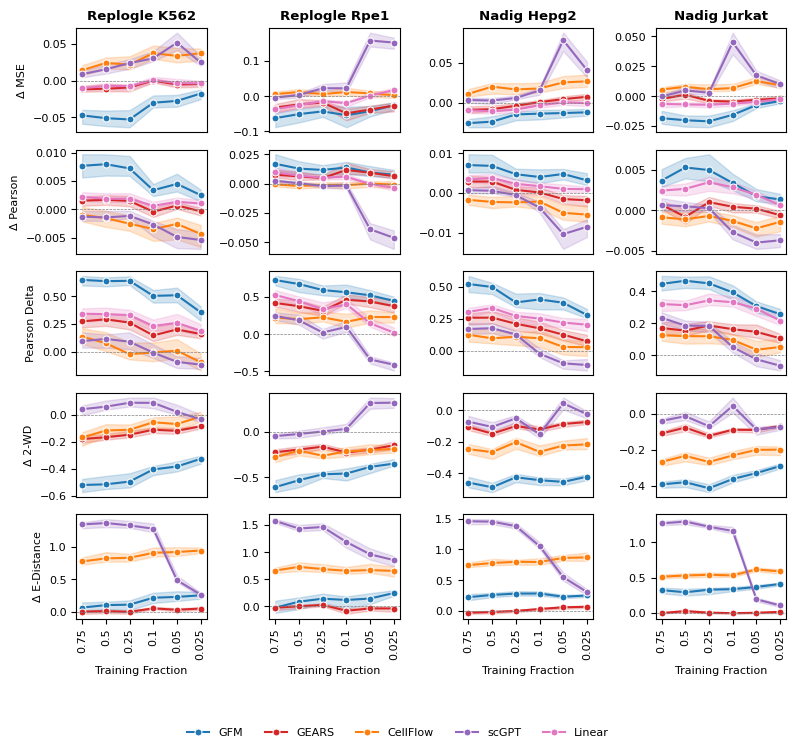

In [ ]:
# Create comprehensive grid plot with all metrics and datasets
metrics_to_plot = ['mse', 'pearson', 'pearson_delta', 'w2d', 'e_distance']  # Add more metrics as available
datasets_to_plot = ['replogle_k562', 'replogle_rpe1', 'nadig_hepg2', 'nadig_jurkat']


plot_metrics_grid(df_all, datasets_to_plot, metrics_to_plot, model_color_dict=model_color_dict,
                  save_path="../data/final_plots/sample_size_test.pdf")